<a href="https://colab.research.google.com/github/gvp2ms/A02-eda-and-visualization/blob/main/a02_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Tiffany Kim

**Date:** 09/10/2026

Index(['ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name'],
      dtype='object')



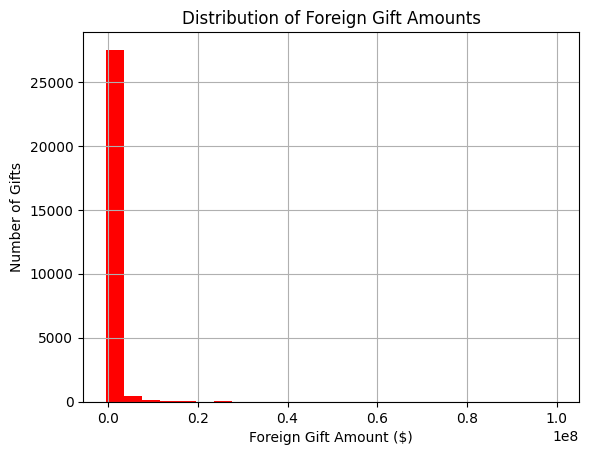

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
The mean is  588232.7172672832
The median is  94615.0
The standard deviation is  3222011.4279505583
The variance is  10381357641843.994

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
As seen by the table, the proportion of gifts that are contracts is 0.612097, 
those that are monetary gifts is 0.387513, and those that are real estate are 0.0000390



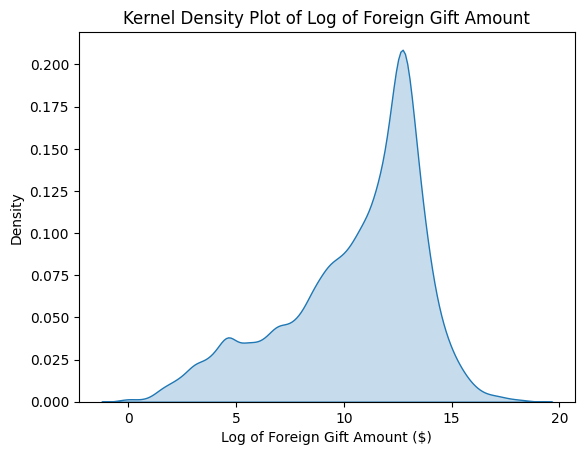

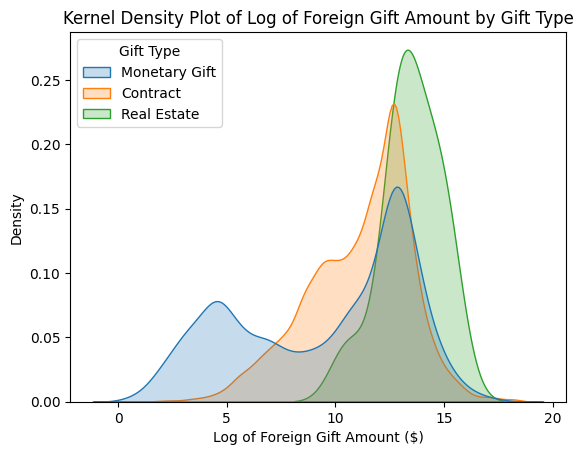

A pattern that I noticed is that the graph of the log of Foreign Gift Amount looks very similar to the graph of the three conditionals combined.
 Both contracts and monetary gifts have a peak around the same place as the log of Foreign Gift Amounts.
Top 15 countries in terms of the number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

Top 15 countries in terms of the amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG           

In [33]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#import dataset
df = pd.read_csv('ForeignGifts_edu.csv')
print(df.columns)
print()

#2 For Foreign Gift Amount, create a histogram and describe the variable. Describe your findings.
df['Foreign Gift Amount'].hist(color = 'red', bins=25)
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Number of Gifts")
plt.title("Distribution of Foreign Gift Amounts")
plt.show()
print(df['Foreign Gift Amount'].describe())
print("The mean is ", df['Foreign Gift Amount'].mean())
print("The median is ", df['Foreign Gift Amount'].median())
print("The standard deviation is ", df['Foreign Gift Amount'].std())
print("The variance is ", df['Foreign Gift Amount'].var())
print()

#3 For Gift Type, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
print(df['Gift Type'].value_counts(normalize=True))
print("As seen by the table, the proportion of gifts that are contracts is 0.612097, \nthose that are monetary gifts is 0.387513, and those that are real estate are 0.0000390")
print()

#4 Create a kernel density plot of the log of Foreign Gift Amount, and then a kernel density plot of the log of Foreign Gift Amount conditional on gift type. Do you notice any patterns?

fga_clean = df[df['Foreign Gift Amount'] > 0].copy()
fga_clean['Log_Gift_Amount'] = np.log1p(fga_clean['Foreign Gift Amount'])
sns.kdeplot(fga_log, fill=True, common_norm = True)
plt.xlabel("Log of Foreign Gift Amount ($)")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Log of Foreign Gift Amount")
plt.show()
print()

sns.kdeplot(data = fga_clean, x='Log_Gift_Amount', hue='Gift Type', fill=True, common_norm = False)

plt.xlabel("Log of Foreign Gift Amount ($)")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Log of Foreign Gift Amount by Gift Type")
plt.show()

print("A pattern that I noticed is that the graph of the log of Foreign Gift Amount looks very similar to the graph of the three conditionals combined.\n Both contracts and monetary gifts have a peak around the same place as the log of Foreign Gift Amounts.")
print()

#5 What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
top_num = df['Country of Giftor'].value_counts().head(15)
print("Top 15 countries in terms of the number of gifts:")
print(top_num)
print()

top_amt = df.groupby('Country of Giftor') ['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("Top 15 countries in terms of the amount given:")
print(top_amt)
print()

#6 Which giftors provide the most money, in total?
df_most_money = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
print("The giftors that provide the most money are: \n", df_most_money.head(15))




## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 8be7fddb8e5ab0281baab86b764ebf9f37dd366b
- **AI tool and model used:** Gemini 3

### *Prompts used

1. Can you go through my code, clean it up and comment on changes you made.
2. Can you check my graphs to make sure that all the histograms are correctly graphed?

### *AI-proposed changes


**Prompt One**

1. Key Observations & Bug Fixes
NameError on fga_log in Question 4:

In your code, you created fga_clean['Log_Gift_Amount'] = np.log1p(...), but then passed fga_log into sns.kdeplot(fga_log, ...) instead of fga_clean['Log_Gift_Amount']. Running this cell as written will throw a NameError: name 'fga_log' is not defined.

2. Negative Values in log1p:

Your filter df['Foreign Gift Amount'] > 0 correctly handles zeros and negative values (the dataset contains a minimum value of -537,770), which prevents NaN or math domain errors when applying np.log1p().

3. Data Quality / Duplicate Country Categories (Q5):

Looking at your output for Q5, both SOUTH KOREA (811) and KOREA (452) appear separately in the top 15 gift count list. Combining or standardizing these string labels would yield a more accurate unified count for Korea.

4. Grouped Giftors (Q6):

Multiple entries represent the same underlying entity under slightly different names (e.g., Qatar Foundation, Qatar Foundation/Qatar National Res, and Qatar Foundation for Education). Aggregating or cleaning these names provides a clearer picture of the true top giftors.

**Prompt Two**
1. Question 2 Histogram (Foreign Gift Amount)Code: df['Foreign Gift Amount'].hist(color='red', bins=25)Issue: The raw distribution of Foreign Gift Amount is extremely right-skewed (values range from negative numbers up to $100,000,000, with a 75th percentile of $376,142). Because a few massive outliers stretch the x-axis out to $10^8$, almost all 28,221 data points get bunched into the very first bin.

2. Question 3 (Gift Type Counts)
Current Code: You used df['Gift Type'].value_counts(normalize=True) to produce a text table rather than generating a visual graph.

Fix/Improvement: The prompt asks to "create a histogram or value counts table." Your normalized value counts table satisfies the prompt requirement directly!

3. Question 4 Kernel Density Estimates (KDEs)
Code & Execution:

In your Phase 2 cell (#34), you correctly updated the plot call to sns.kdeplot(fga_clean['Log_Gift_Amount'], fill=True, common_norm=True).

Filtering out non-positive values (df['Foreign Gift Amount'] > 0) before applying np.log1p() is mathematically sound and avoids NaN errors from negative gift values.

common_norm=False on the conditional plot properly scales each gift type's density curve independently so that rare categories (like Real Estate) remain readable alongside dominant ones (Contracts/Monetary).

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Modify | I misused some of the variables I created, like using fga_clean instead of fga_log. However, I didn't run into the issues the AI said I would. Also, the AI misinterpreted some of the names of the giftors, so that suggestion can be ignored.  |
| 2 | Accept | The suggestions it gave were helpful and allowed me to simplify my code and make it more organized. I also preferred the idea of making a bar graph to represent each conditional rather than a histograph, because it's three different qualitatitve groups.

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Index(['ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name'],
      dtype='object')



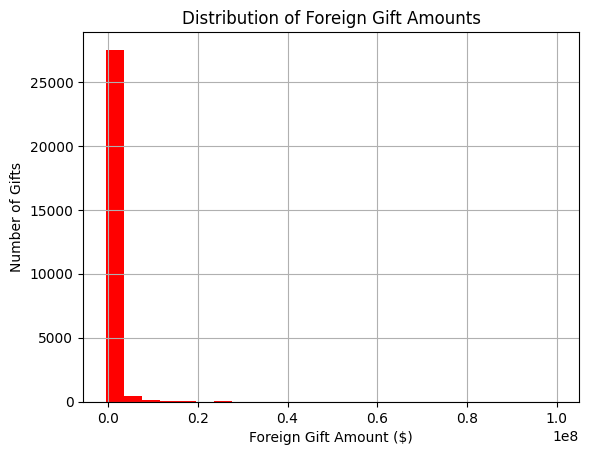

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
The mean is  588232.7172672832
The median is  94615.0
The standard deviation is  3222011.4279505583
The variance is  10381357641843.994

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


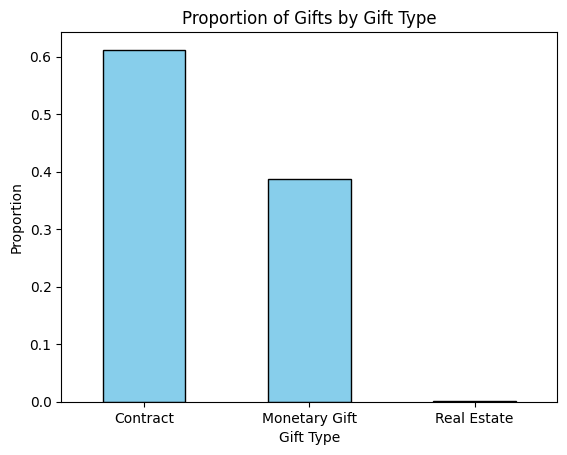

As seen by the table, the proportion of gifts that are contracts is 0.612097, 
those that are monetary gifts is 0.387513, and those that are real estate are 0.0000390



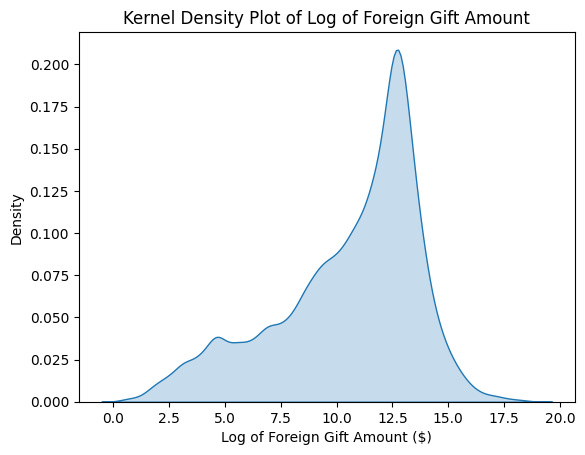

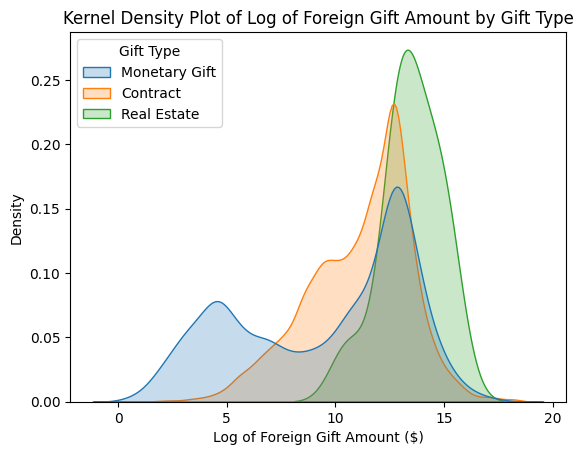

A pattern that I noticed is that the graph of the log of Foreign Gift Amount looks very similar to the graph of the three conditionals combined.
 Both contracts and monetary gifts have a peak around the same place as the log of Foreign Gift Amounts.

Top 15 countries in terms of the number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

Top 15 countries in terms of the amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG          

In [37]:
# Your Phase 2 solution to the problem goes here.

#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#import dataset
df = pd.read_csv('ForeignGifts_edu.csv')
print(df.columns)
print()

#2 For Foreign Gift Amount, create a histogram and describe the variable. Describe your findings.
df['Foreign Gift Amount'].hist(color = 'red', bins=25)
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Number of Gifts")
plt.title("Distribution of Foreign Gift Amounts")
plt.show()
print(df['Foreign Gift Amount'].describe())
print("The mean is ", df['Foreign Gift Amount'].mean())
print("The median is ", df['Foreign Gift Amount'].median())
print("The standard deviation is ", df['Foreign Gift Amount'].std())
print("The variance is ", df['Foreign Gift Amount'].var())
print()

#3 For Gift Type, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
print(df['Gift Type'].value_counts(normalize=True))

df['Gift Type'].value_counts(normalize=True).plot(kind='bar', color='skyblue', edgecolor='black')
plt.ylabel("Proportion")
plt.title("Proportion of Gifts by Gift Type")
plt.xticks(rotation=0)
plt.show()

print("As seen by the table, the proportion of gifts that are contracts is 0.612097, \nthose that are monetary gifts is 0.387513, and those that are real estate are 0.0000390")
print()

#4 Create a kernel density plot of the log of Foreign Gift Amount, and then a kernel density plot of the log of Foreign Gift Amount conditional on gift type. Do you notice any patterns?

fga_clean = df[df['Foreign Gift Amount'] > 0].copy()
fga_clean['Log_Gift_Amount'] = np.log1p(fga_clean['Foreign Gift Amount'])
sns.kdeplot(fga_clean['Log_Gift_Amount'], fill=True, common_norm = True)
plt.xlabel("Log of Foreign Gift Amount ($)")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Log of Foreign Gift Amount")
plt.show()
print()

sns.kdeplot(data = fga_clean, x='Log_Gift_Amount', hue='Gift Type', fill=True, common_norm = False)

plt.xlabel("Log of Foreign Gift Amount ($)")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Log of Foreign Gift Amount by Gift Type")
plt.show()

print("A pattern that I noticed is that the graph of the log of Foreign Gift Amount looks very similar to the graph of the three conditionals combined.\n Both contracts and monetary gifts have a peak around the same place as the log of Foreign Gift Amounts.")
print()

#5 What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
top_num = df['Country of Giftor'].value_counts().head(15)
print("Top 15 countries in terms of the number of gifts:")
print(top_num)
print()

top_amt = df.groupby('Country of Giftor') ['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("Top 15 countries in terms of the amount given:")
print(top_amt)
print()

#6 Which giftors provide the most money, in total?
df_most_money = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
print("The giftors that provide the most money are: \n", df_most_money.head(15))


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or
limitations, how the final solution was verified, and any remaining concerns.]

AI did very well in assisting and cleaning up the developing of the diffent histograms, kernel density equation plots, and bar graphs. I don't have much experience in statistical analysis with Python or Pandas, so AI was able to help me find quicker or more simplified solutions to the questions. It also helped me revise my code so that I used all the proper variables that I created, focused on the right parts of the database, and made my code more cleaner and legible. AI was a great tool at cleaning up code and using the specific methods that Pandas and Seaborn have for creating graphs.
However, one major downside of AI that I found was that it cannot distinguish between actual naming conventions and other duplicate data. Sometimes, there is duplicate data in a dataset and AI is quick to catch on to that and clean it up easily. But sometimes, for example in the case of the giftors that provided the most money, some of the giftors had incredibly similar names. AI couldn't tell the fact that these were all intentionally different companies and recommended that I combine all of them together. So for examples like that, it would likely better that a human read through the AI generated suggestions and provide their own judgement.